<a href="https://colab.research.google.com/github/VladimirSharaP/Linear_Regression/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Подключение библиотек

In [ ]:
# Работа с массивами
import numpy as np

# Работа с таблицами
import pandas as pd


import keras
# Построение моделей нейронных сетей
from keras.models import Sequential, Model

# Слои
from keras.layers import concatenate, Input, Dense, Dropout, BatchNormalization
from keras.layers import Flatten, Conv1D, Conv2D, LSTM, GlobalMaxPooling1D
from keras.layers import MaxPooling1D, RepeatVector

# Оптимизаторы
from keras.optimizers import Adam

# Генератор выборки временных рядов
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

# Нормировка
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Отрисовка графиков
import matplotlib.pyplot as plt
%matplotlib inline

# Назначение размера и стиля графиков по умолчанию
from pylab import rcParams
plt.style.use('ggplot')
rcParams['figure.figsize'] = (14, 7)

# Отключение лишних предупреждений
import warnings
warnings.filterwarnings('ignore')

Загрузка и предобработка данных

In [ ]:
# импортируем файл с данными о котировках акций Apple
!wget https://storage.yandexcloud.net/academy.ai/AAPL.csv

# Загрузим только необходимые колонки usecols, укажем, что колонку Date необходимо преобразовать в формат DateTime (parse_dates) и сделать индексом index_col
price = pd.read_csv("./AAPL.csv", index_col='Date', usecols = ['Adj Close', 'Volume', 'Date'], parse_dates=['Date'])
price.head()

--2024-11-10 12:28:33--  https://storage.yandexcloud.net/academy.ai/AAPL.csv
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 186539 (182K) [text/csv]
Saving to: ‘AAPL.csv’

AAPL.csv            100%[===================>] 182.17K   310KB/s    in 0.6s    

2024-11-10 12:28:34 (310 KB/s) - ‘AAPL.csv’ saved [186539/186539]



,Adj Close,Volume
Date,,
2014-01-02,17.296652,234684800
2014-01-03,16.916719,392467600
2014-01-06,17.008968,412610800
2014-01-07,16.887323,317209200
2014-01-08,16.994270,258529600


Визуализация данных

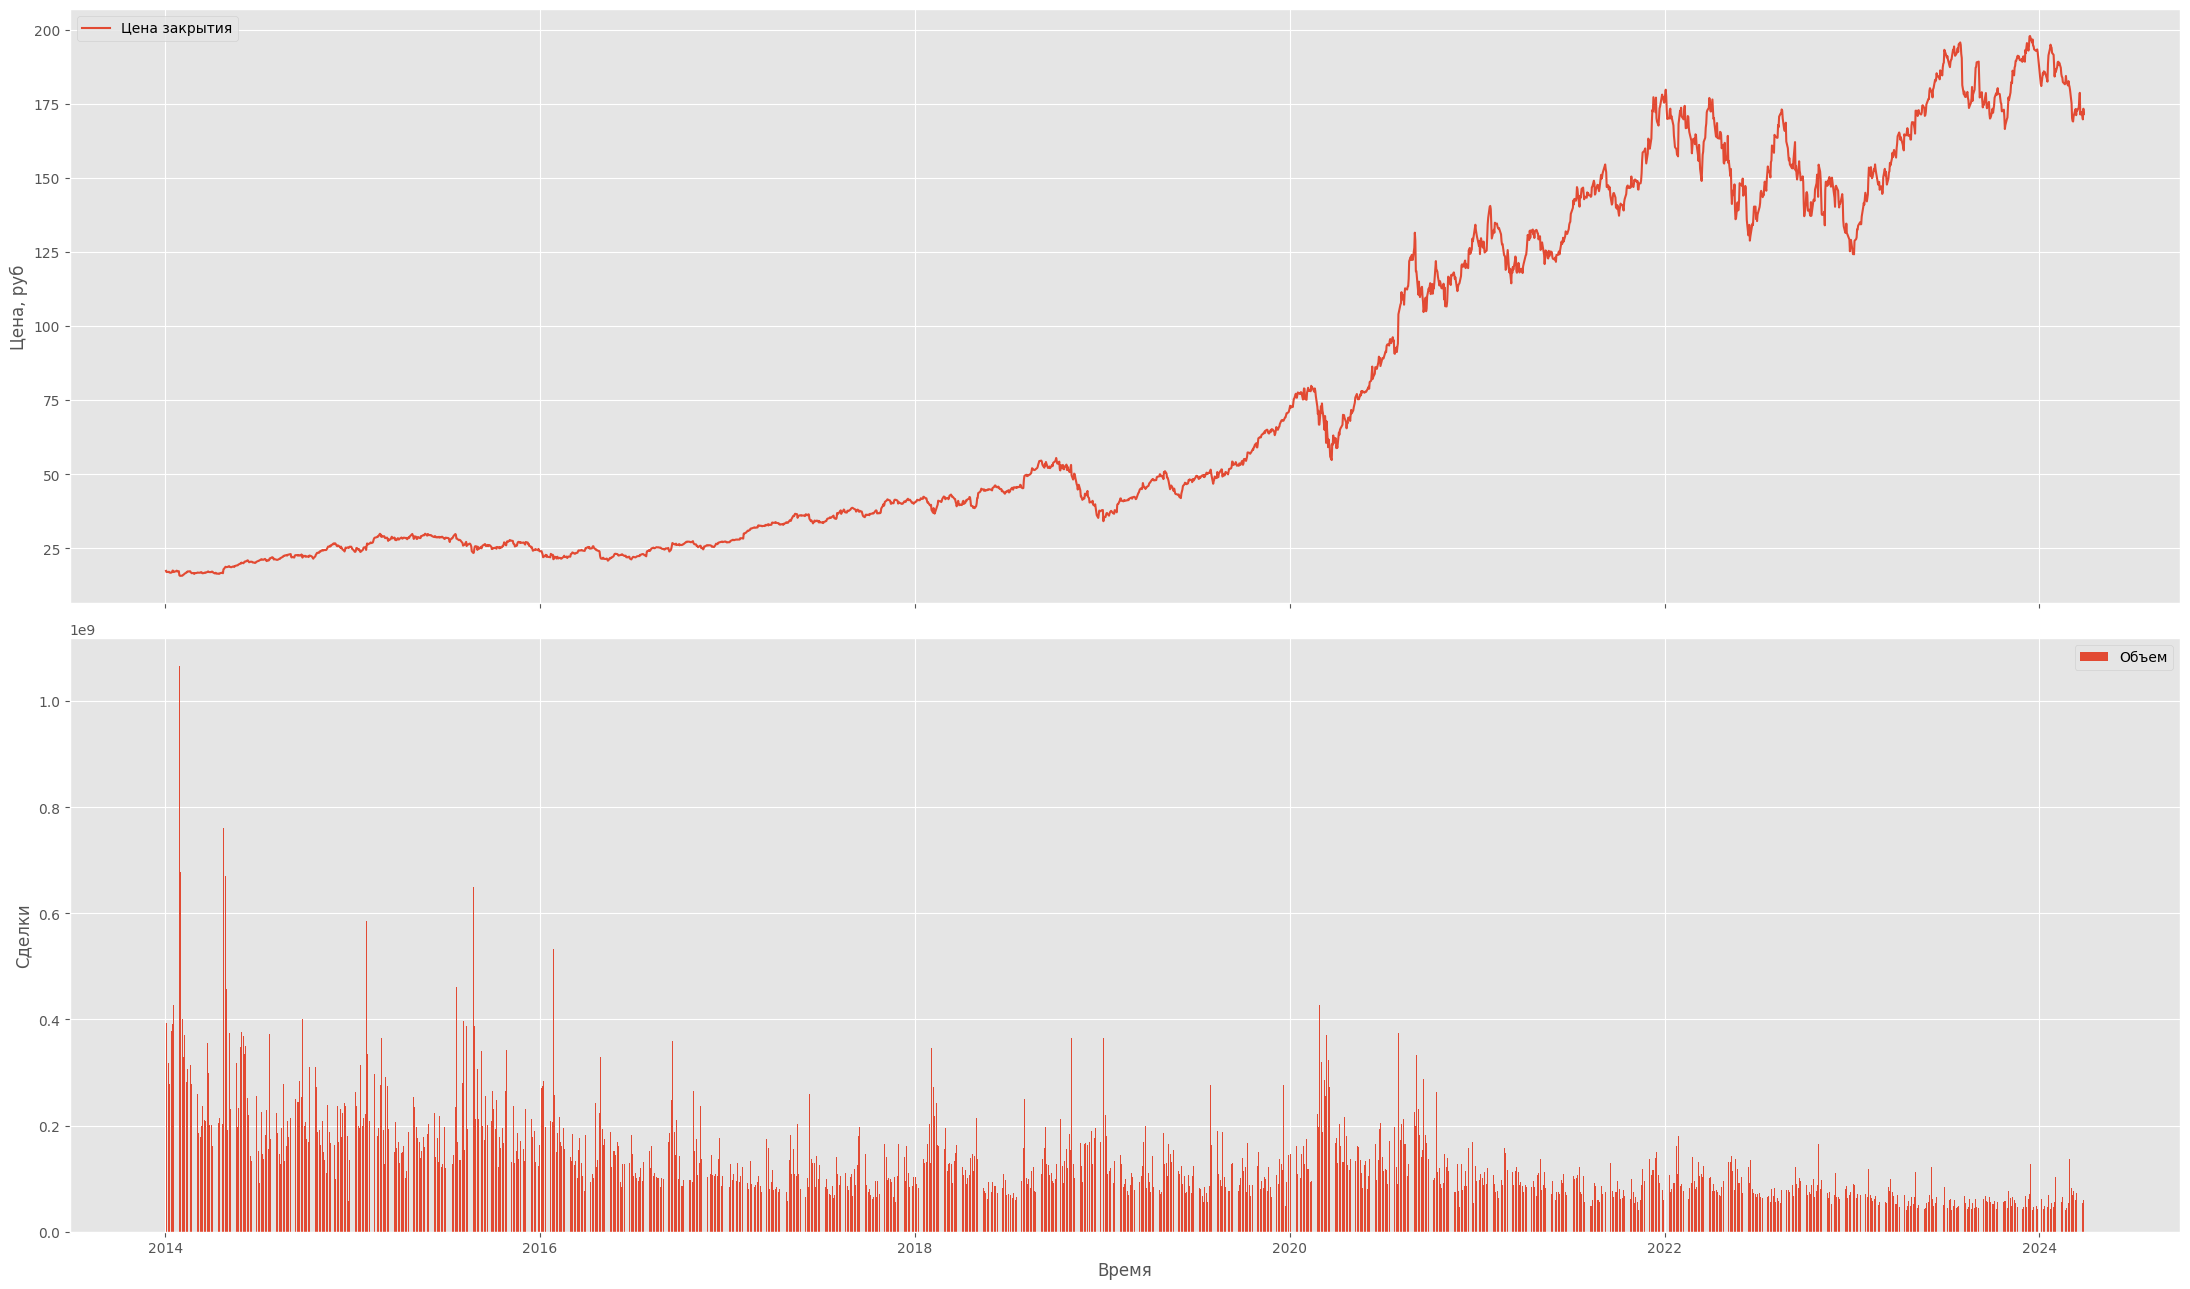

In [ ]:
# Задание полотна для графиков - два подграфика один под другим с общей осью x
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(22, 13), sharex=True)


# Отрисовка одного канала данных
# От начальной точки start длиной length
ax1.plot(price.index, price['Adj Close'], label='Цена закрытия')

ax1.set_ylabel('Цена, руб')
ax1.legend()

# Канал volume (объем)
ax2.bar(x=price.index,
        height=price['Volume'],
        label='Объем')
ax2.set_ylabel('Сделки')
ax2.legend()

plt.xlabel('Время')
# Регулировка пределов оси x
# plt.xlim(0, length)
# Указание расположить подграфики плотнее друг к другу
plt.tight_layout()
# Фиксация графика
plt.show()

In [ ]:
price.drop(columns=['Volume'], inplace=True)

In [ ]:
price.head()

,Adj Close
Date,
2014-01-02,17.296652
2014-01-03,16.916719
2014-01-06,17.008968
2014-01-07,16.887323
2014-01-08,16.994270


In [ ]:
train_data = price[:'2023-01-10']
test_data = price['2023-01-20':]

Нормализация данных и подготовка обучающей, проверочной и тестовой выборок

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(train_data)
scaled_train_data = scaler.transform(train_data)
scaled_test_data = scaler.transform(test_data)

In [ ]:
# Проверка формы данных
print(f'Тренировочные данные: {scaled_train_data.shape}')
print(f'Тестовые данные: {scaled_test_data.shape}')

Тренировочные данные: (2271, 1)
Тестовые данные: (299, 1)


In [ ]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator


n_input = 4  # Размерность входных данных
n_features = 1 # Размерность выходных данных
BATCH_SIZE = 3  # Размер пакета

generator = TimeseriesGenerator(scaled_train_data, scaled_train_data, length=n_input, batch_size=BATCH_SIZE)
print(f'Форма обучающего пакета: {generator[0][0].shape}, y: {generator[0][1].shape}')

Форма обучающего пакета: (3, 4, 1), y: (3, 1)


In [ ]:
validator = TimeseriesGenerator(scaled_test_data, scaled_test_data, length=n_input, batch_size=BATCH_SIZE)
print(f'Форма валидационного пакета: {validator[0][0].shape}, y: {validator[0][1].shape}')

Форма валидационного пакета: (3, 4, 1), y: (3, 1)


In [ ]:
tester = TimeseriesGenerator(scaled_test_data, scaled_test_data, length=n_input, batch_size=scaled_test_data.shape[0])
x_test, y_test = tester[0]
print(f'Форма тестовой выборки: {x_test.shape}, y: {y_test.shape}')

Форма тестовой выборки: (295, 4, 1), y: (295, 1)


Вспомогательные функции

In [ ]:
# Объявление функции графика обучения
def history_plot(history, title):

    # Рисование графиков обучения
    fig = plt.figure(figsize=(14, 7))
    plt.plot(history.history['loss'], label='Ошибка на обучающем наборе')
    plt.plot(history.history['val_loss'], label='Ошибка на проверочном наборе')
    plt.title(f'{title}. График обучения')

    # Показываем только целые метки шкалы оси x
    fig.gca().xaxis.get_major_locator().set_params(integer=True)
    plt.xlabel('Эпоха обучения')
    plt.ylabel('Средняя ошибка')
    plt.legend()
    plt.show()

# Функция расчета корреляции для двух рядов
def correlate(a, b):
    return np.corrcoef(a, b)[0, 1]

# Функция визуализации результата предсказания сети и верных ответов

def show_predict(y_pred, y_true, title=''):
    fig = plt.figure(figsize=(14, 7))
    # Прогнозный ряд сдвигается на 1 шаг назад, так как предсказание делалось на 1 шаг вперед
    plt.plot(y_pred[1:], label=f'Прогноз')
    plt.plot(y_true[:-1], label=f'Базовый')
    plt.title(title)

    # Показываем только целые метки шкалы оси x
    fig.gca().xaxis.get_major_locator().set_params(integer=True)
    plt.xlabel('Дата (относительно начала выборки)')
    plt.ylabel('Значение')
    plt.legend()
    plt.show()

# Функция расчета результата предсказания
def get_pred(model, # модель
             x_test, y_test, # тестовая выборка
             y_scaler): # масштабирующий объект для y

    # Вычисление и деномализация предсказания
    y_pred_unscaled = y_scaler.inverse_transform(model.predict(x_test, verbose=0))

    # Денормализация верных ответов
    y_test_unscaled = y_scaler.inverse_transform(y_test)

    # Возврат результата предсказания и верные ответы в исходном масштабе
    return y_pred_unscaled, y_test_unscaled



# Функция рисования корреляций прогнозного ряда и исходного со смещением
# break_step - ограничитель на число временных лагов

def show_corr(y_pred, y_true, title='', break_step=30):

    # выбираем наименьшее из длины y_len и break_step в качестве числа лагов для графика
    y_len = y_true.shape[0]
    steps = range(1, np.min([y_len+1, break_step+1]))

    # Вычисление коэффициентов корреляции базового ряда и предсказания с разным смещением
    cross_corr = [correlate(y_true[:-step, 0], y_pred[step:, 0]) for step in steps]

    # Вычисление коэффициентов автокорреляции базового ряда с разным смещением
    auto_corr = [correlate(y_true[:-step, 0], y_true[step:, 0]) for step in steps]

    plt.plot(steps, cross_corr, label=f'Прогноз')
    plt.plot(steps, auto_corr, label=f'Эталон')

    plt.title(title)

    # Назначение меток шкалы оси x
    plt.xticks(steps)
    plt.xlabel('Шаги смещения')
    plt.ylabel('Коэффициент корреляции')
    plt.legend()
    plt.show()

Инициализация модели

In [ ]:
# Простая полносвязная сеть
model_dense = Sequential()
model_dense.add(Dense(220, input_shape=generator[0][0].shape[1:], activation='relu'))
model_dense.add(Dense(80, activation='relu'))
model_dense.add(Dense(30, activation='relu'))
model_dense.add(Flatten())
model_dense.add(Dense(100, activation='relu'))
model_dense.add(Dense(n_features, activation='linear'))

model_dense.compile(optimizer='adam', loss='mse')
model_dense.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 4, 220)              │             440 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4, 80)               │          17,680 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4, 30)               │           2,430 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 120)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 100)                 │          12,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │             101 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 32,751 (127.93 KB)

 Trainable params: 32,751 (127.93 KB)

 Non-trainable params: 0 (0.00 B)

Обучение модели

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(filepath = 'best_model_pretrain.keras',
                             monitor = 'val_loss',
                             save_best_only = True,
                             mode = 'min',
                             verbose = 0)
]

model_dense.fit(generator, epochs=200, validation_data=validator, callbacks=callbacks)

Epoch 1/200
756/756 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0090 - val_loss: 0.0069
Epoch 2/200
756/756 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0012 - val_loss: 4.4091e-04
Epoch 3/200
756/756 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5.7680e-04 - val_loss: 0.0064
Epoch 4/200
756/756 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 7.7691e-04 - val_loss: 5.6001e-04
Epoch 5/200
756/756 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 5.6742e-04 - val_loss: 0.0013
Epoch 6/200
756/756 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3.8058e-04 - val_loss: 2.9842e-04
Epoch 7/200
756/756 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5.7123e-04 - val_loss: 8.1858e-04
Epoch 8/200
756/756 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5.1119e-04 - val_loss: 2.7865e-04
Epoch 9/200
756/756 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4.2042e-04 - val_loss: 4.3381e-04
Epoch 10/200
756/756 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3.4494e-04 - val_loss: 3.0229e-04
Epoch 11/200
756/756 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 3.1712e

Анализ результатов

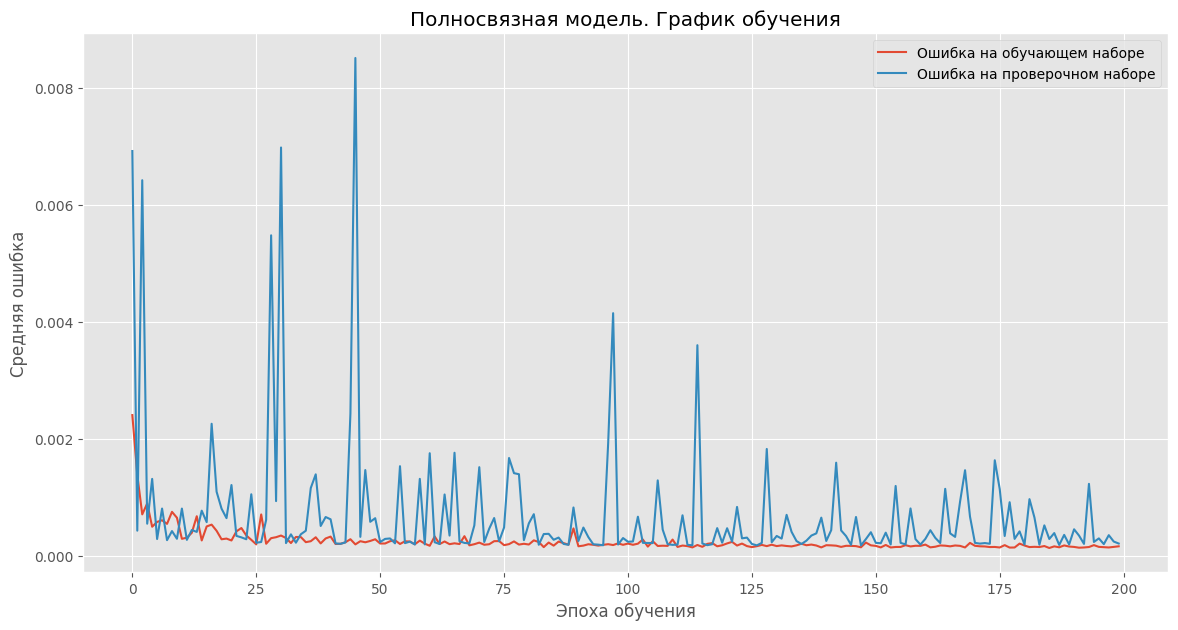

In [ ]:
history_plot(model_dense.history, 'Полносвязная модель')

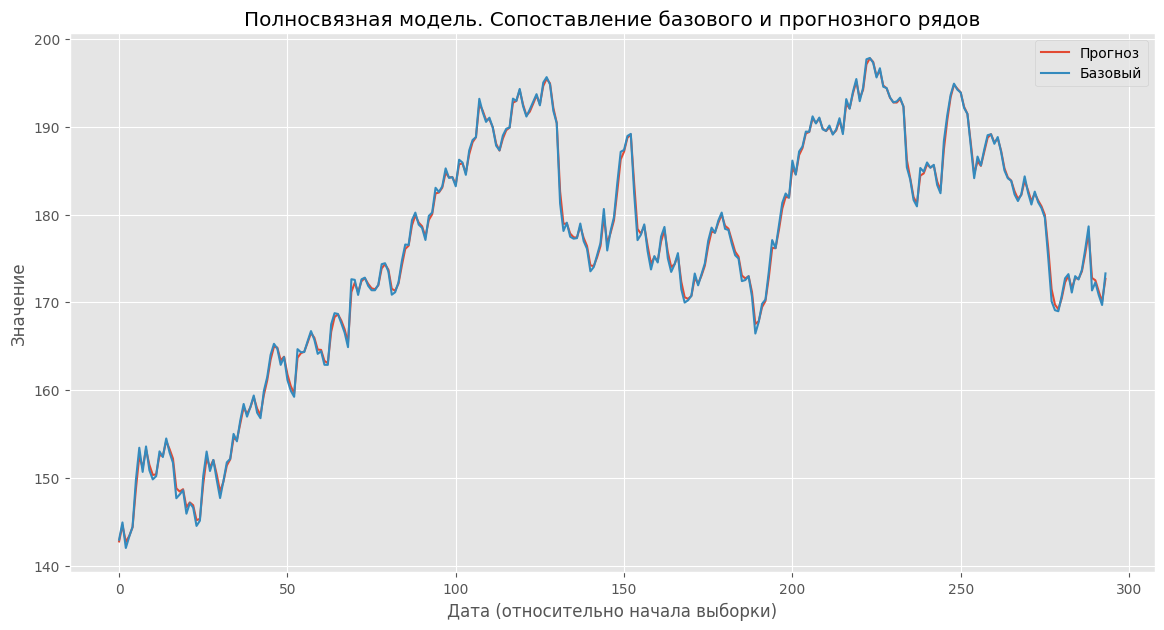

In [ ]:
model_dense = keras.models.load_model('best_model_pretrain.keras')

# Получение денормализованного предсказания и данных базового ряда
y_pred, y_true = get_pred(model_dense, x_test, y_test, scaler)

# Отрисовка графика сопоставления базового и прогнозного рядов
show_predict(y_pred, y_true, title=f'Полносвязная модель. Сопоставление базового и прогнозного рядов')

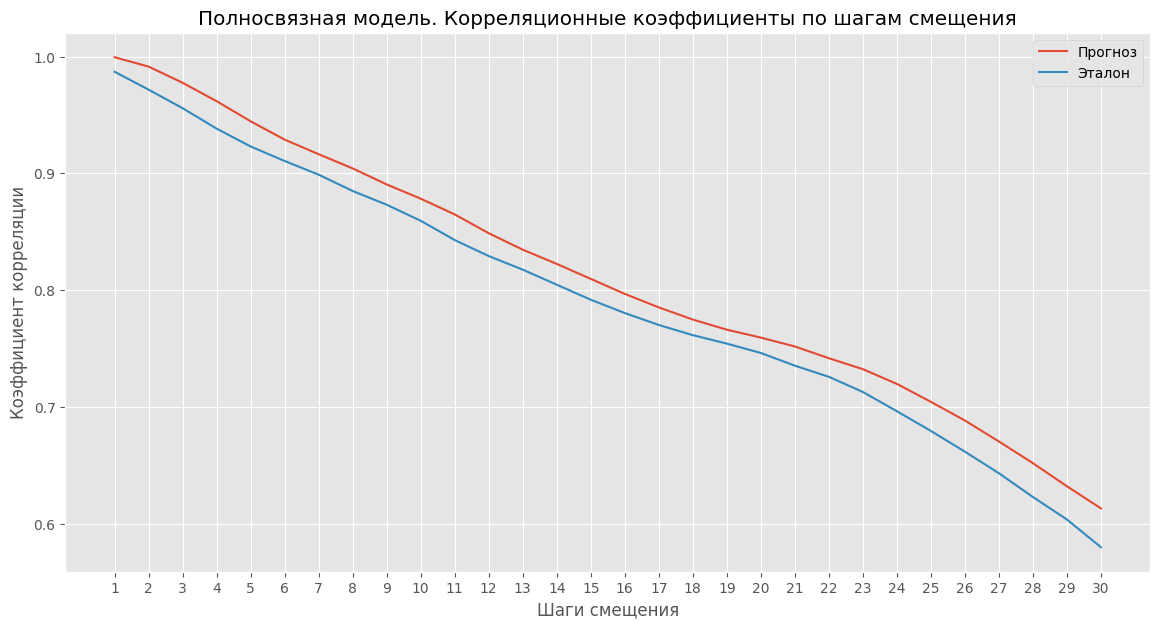

In [ ]:
# Отрисовка графика корреляционных коэффициентов до заданного максимума шагов смещения
show_corr(y_pred, y_true, title=f'Полносвязная модель. Корреляционные коэффициенты по шагам смещения')

Дифференцирование датасета

In [ ]:
price.head()

,Adj Close
Date,
2014-01-02,17.296652
2014-01-03,16.916719
2014-01-06,17.008968
2014-01-07,16.887323
2014-01-08,16.994270


In [ ]:
price['Adj Close'] = price['Adj Close'].diff()

In [ ]:
price.head()

,Adj Close
Date,
2014-01-02,NaN
2014-01-03,-0.379933
2014-01-06,0.092249
2014-01-07,-0.121645
2014-01-08,0.106947


In [ ]:
train_data = price['2014-01-03':'2023-01-10']
test_data = price['2023-01-20':]

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(train_data)
scaled_train_data = scaler.transform(train_data)
scaled_test_data = scaler.transform(test_data)

from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator


n_input = 4  # Размерность входных данных
n_features = 1 # Размерность выходных данных
BATCH_SIZE = 3  # Размер пакета

generator = TimeseriesGenerator(scaled_train_data, scaled_train_data, length=n_input, batch_size=BATCH_SIZE)
print(f'Форма обучающего пакета: {generator[0][0].shape}, y: {generator[0][1].shape}')

validator = TimeseriesGenerator(scaled_test_data, scaled_test_data, length=n_input, batch_size=BATCH_SIZE)
print(f'Форма валидационного пакета: {validator[0][0].shape}, y: {validator[0][1].shape}')

tester = TimeseriesGenerator(scaled_test_data, scaled_test_data, length=n_input, batch_size=scaled_test_data.shape[0])
x_test, y_test = tester[0]
print(f'Форма тестовой выборки: {x_test.shape}, y: {y_test.shape}')

model_dense_diff = Sequential()
model_dense_diff.add(Flatten())
model_dense_diff.add(Dense(n_features, activation='linear'))

model_dense_diff.compile(optimizer='adam', loss='mse')
model_dense_diff.summary()

callbacks = [
    keras.callbacks.ModelCheckpoint(filepath = 'best_model_diff.keras',
                             monitor = 'val_loss',
                             save_best_only = True,
                             mode = 'min',
                             verbose = 0)
]

model_dense_diff.fit(generator, epochs=20, validation_data=validator, callbacks=callbacks)

Форма обучающего пакета: (3, 4, 1), y: (3, 1)
Форма валидационного пакета: (3, 4, 1), y: (3, 1)
Форма тестовой выборки: (295, 4, 1), y: (295, 1)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0194 - val_loss: 0.0173
Epoch 2/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0111 - val_loss: 0.0154
Epoch 3/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0112 - val_loss: 0.0139
Epoch 4/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0080 - val_loss: 0.0128
Epoch 5/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0079 - val_loss: 0.0119
Epoch 6/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0088 - val_loss: 0.0114
Epoch 7/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0065 - val_loss: 0.0110
Epoch 8/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0071 - val_loss: 0.0107
Epoch 9/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0065 - val_loss: 0.0105
Epoch 10/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0066 - val_loss: 0.0105
Epoch 11/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0059 - val_loss: 0.0105
Epoch 12/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

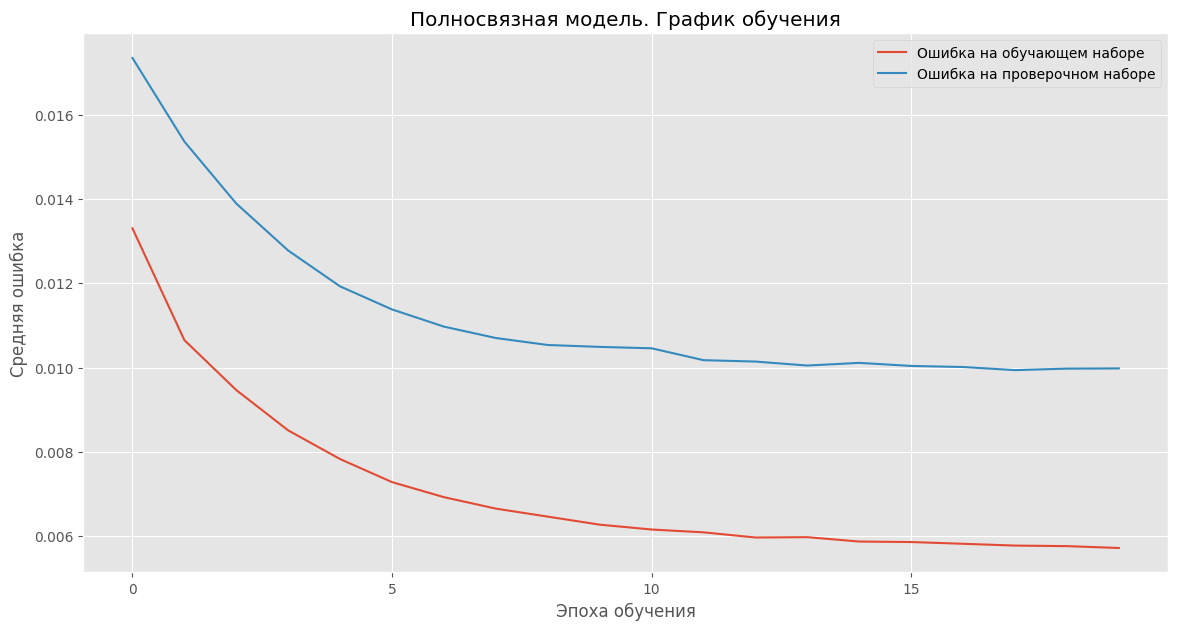

In [ ]:
history_plot(model_dense_diff.history, 'Полносвязная модель')

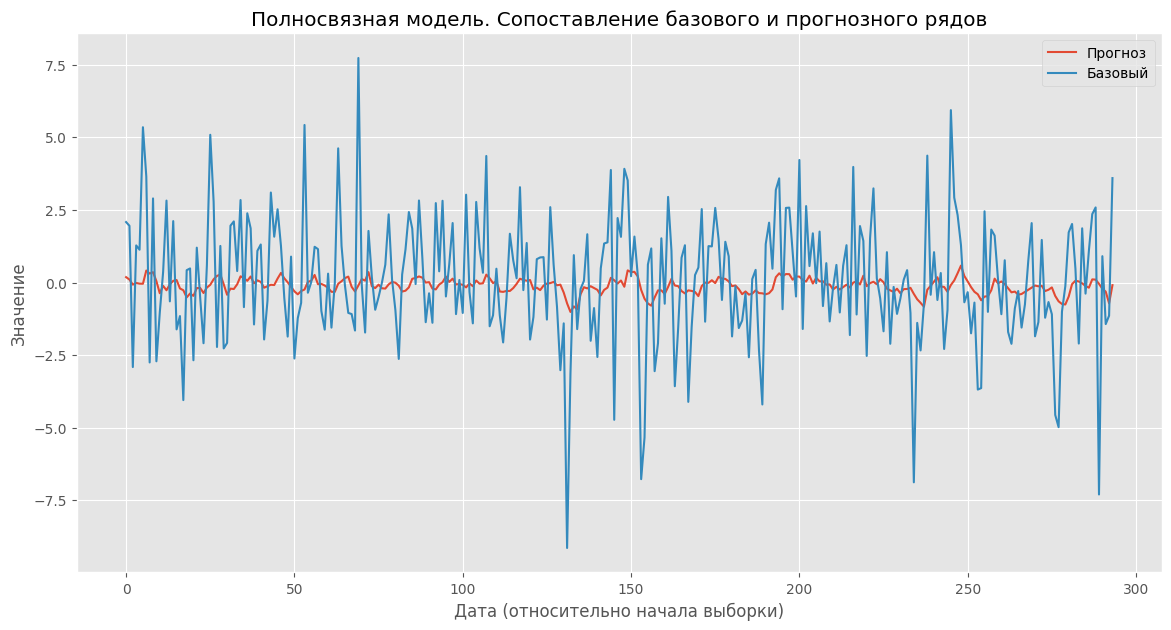

In [ ]:
model_dense = keras.models.load_model('best_model_diff.keras')

# Получение денормализованного предсказания и данных базового ряда
y_pred, y_true = get_pred(model_dense_diff, x_test, y_test, scaler)

# Отрисовка графика сопоставления базового и прогнозного рядов
show_predict(y_pred, y_true, title=f'Полносвязная модель. Сопоставление базового и прогнозного рядов')

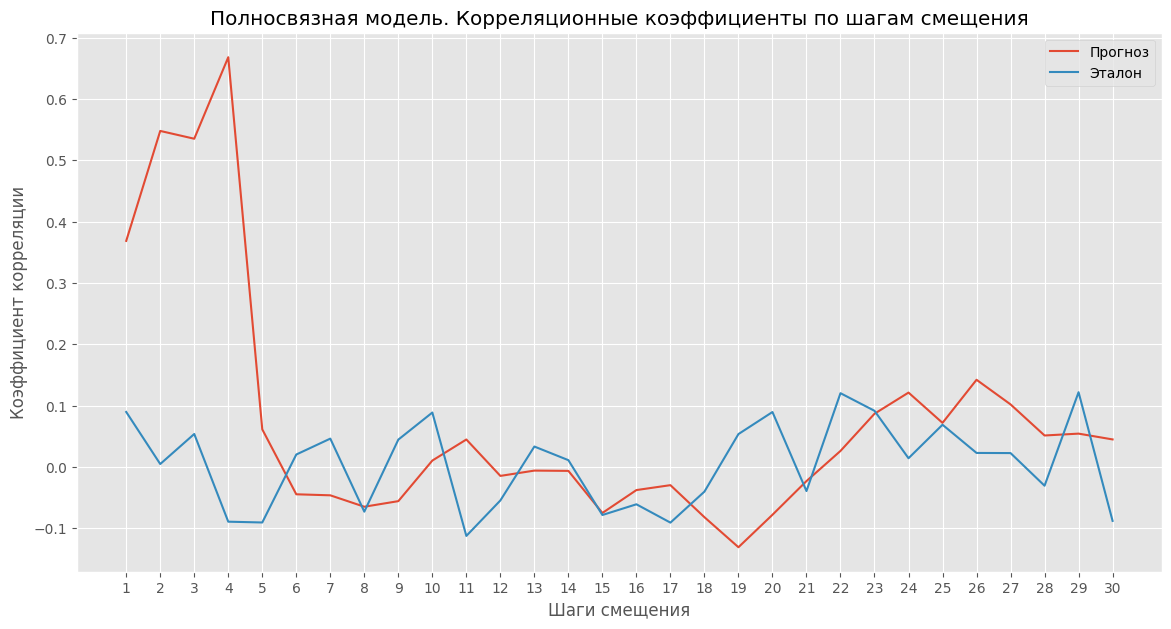

In [ ]:
show_corr(y_pred, y_true, title=f'Полносвязная модель. Корреляционные коэффициенты по шагам смещения')